## Example Code and basic Data Analysis

### Project Introduction

Welcome to the Customer Analytics project!

#### About the Project

You and your team will work with real financial data from a small bank in Switzerland. The data is aggregated from 3 years of credit card transactions (2021–2023).

There are two different aggregations:

#### Customer Statistics

Statistics for each customer

| Column            | Description     |
|-------------------|-----------------|
|customer_id        | Unique Id                             |
|n_country          | Card used in number of countries      |
|n_transactions     | Number of transactions                |
|total_amount       | Total amount spent                    | 
|n_counterparts     | Number of unique counterparts         |
|days_active        | Number of days the card was active (last transaction - first transaction)     |
|pos_perc           | Point of sale (in store) percentage of total amount |     
|ecom_perc          | E-commerce (online) percentage of total amount |            
|                   |       |
| *Categories*      | Total amount spent per category                             |
|                   |       |
|education          |       |
|entertainment      |       |
|fitness            |       |
|...                |       |
|                   |       |
| *Currencies*          | Total amount spent in currency (only top currencies)       |
|                   |       |
|chf                |       |
|eur                |       |
| ...               |       |
|                   |       |
| *Countries*         | Total amount spent in country (only top countries)       |
|                   |       |
|ch                 |       |
|de                 |       |
| ...               |       |




#### Share of Wallet

Share of wallet for each month for each category or category and top counterpart for all customers.

| Column            | Description     |
|-------------------|-----------------|
|month              | Month of the year          |
|year               | Year           |
|category           | Category          |
|top_counterpart    | Top counterpart           |
|n_customers        | Number of individual customers who had a transaction per month/category/top_counterpart          |
|n_transasctions    | Number of individual transactions per month/category/top_counterpart          |
|total_amount       | Total amount spend per month/category/top_counterpart          |
|pos_perc           | Point of sale (in store) percentage of total amount |     
|ecom_perc          | E-commerce (online) percentage of total amount |      



### Loading the Data

We use Pandas to read one of the csv files and display the first 5 rows.

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv("customer_data.csv")

# Show the first 5 rows
df.head()

,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,...,cur_mxn,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us
0,0,11,197,21843.61,92,514,0.75,0.25,12620.0,1638.0,...,0.0,0.0,19.25,86.0,0.0,0.0,16.0,28.0,42.0,0.0
1,1,14,1736,104203.28,468,964,0.54,0.46,11233.0,2231.0,...,0.0,0.0,786.15,1325.0,9.0,1.0,5.0,146.0,96.0,4.0
2,2,31,3087,197449.56,629,964,0.21,0.79,15395.0,8950.0,...,0.0,0.0,27091.00,1632.0,106.0,3.0,93.0,11.0,0.0,59.0
3,3,5,1412,49291.32,127,930,0.96,0.04,1450.0,291.0,...,0.0,0.0,0.00,1291.0,103.0,0.0,0.0,0.0,0.0,7.0
4,4,5,903,8224.79,183,525,0.95,0.05,0.0,0.0,...,0.0,0.0,0.00,884.0,9.0,0.0,0.0,0.0,8.0,0.0


We can see the available columns and the first few values.

First lets check the dimenstions of our data:

In [2]:
print(len(df))
print(df.shape)

5576
(5576, 42)


We have 5576 distinct customers in our dataset with 42 attributes.

In [3]:
df["n_transactions"].describe()

count    5576.000000
mean      237.215746
std       440.771088
min         1.000000
25%         7.000000
50%        49.000000
75%       260.000000
max      5732.000000
Name: n_transactions, dtype: float64

We can see that the average number of transactions is 237.2, the lowest number is 1 and the highest 5732.

We can do the same for all the different columsn available.

In [4]:
df["total_amount"].describe()

count      5576.000000
mean      10799.021065
std       22902.365173
min           0.050000
25%         150.225000
50%        1864.725000
75%       10734.857500
max      333261.570000
Name: total_amount, dtype: float64

### Calculate Total Spending

In [5]:
# Total spending across all transactions
total_spending = df["total_amount"].sum()

print(f"Total spending: CHF {total_spending}")

Total spending: CHF 60215341.46000001


We can check this against the data from before. We saw 5576 customer with an average total amount of 10799.

In [6]:
5576 * 10799

60215224

### Calculate the grocery spending and SoW

We filter the data to only include transactions within the "Groceries" category. Then we calculate the sum as we did before.

In [7]:
# Filter only Groceries
grocery_spending = df["cat_groceries"].sum()

print(f"Grocery spending: CHF {grocery_spending:.2f}")

Grocery spending: CHF 10443479.00


In [8]:
# Calculate share of wallet
share_of_wallet_groceries = (grocery_spending / total_spending) * 100

print(f"Share of wallet for Groceries: {share_of_wallet_groceries:.1f}%")

Share of wallet for Groceries: 17.3%


### Visualize

This time we calculate the spend per category for all available categories. To do this we use a groupby aggregation. We group by category and calculate the sum for each.

First we filter all category columns

In [9]:
category_cols = [col for col in df.columns if col.startswith("cat_")]
print(category_cols)

['cat_cash', 'cat_communication', 'cat_education', 'cat_entertainment', 'cat_fitness', 'cat_general', 'cat_groceries', 'cat_health', 'cat_holidays', 'cat_hotel', 'cat_lebensmittel', 'cat_living', 'cat_restaurant', 'cat_restaurants', 'cat_salary', 'cat_savings', 'cat_shopping', 'cat_tax', 'cat_transport', 'cat_wellness']


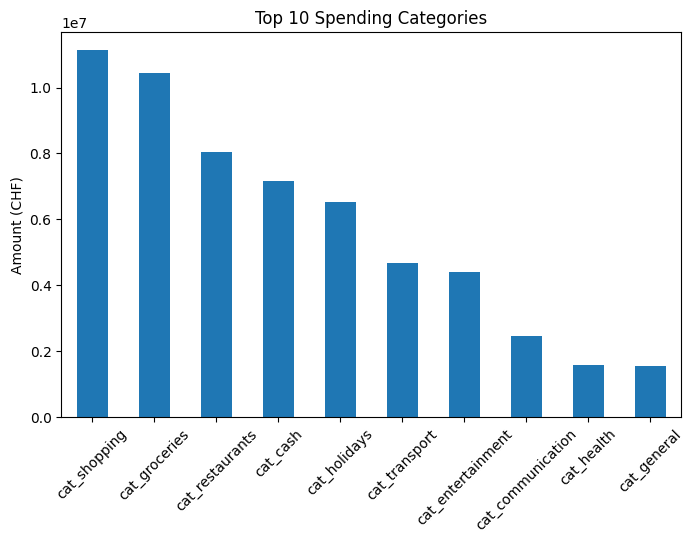

In [10]:
import matplotlib.pyplot as plt

top_n = 10

# Plot top 5 categories
df[category_cols].sum().sort_values(ascending=False)[:top_n].plot(
    kind="bar", figsize=(8, 5)
)
plt.title(f"Top {top_n} Spending Categories")
plt.ylabel("Amount (CHF)")
plt.xticks(rotation=45)
plt.show()

### SOW Data

In [ ]:
sow_df = pd.read_csv("sow_category_counterpart.csv")
sow_df.head(5)

,year_month,category,top_counterpart,n_customers,n_transasctions,total_amount,pos_perc,ecom_perc
0,3-2023,communication,apple,359,1019,15750.20,0.00,1.00
1,3-2023,restaurants,sumup,197,388,9395.06,1.00,0.00
2,3-2023,groceries,avec,157,344,2776.40,0.99,0.01
3,3-2023,restaurants,uber,59,176,7540.18,0.07,0.93
4,3-2023,transport,parkingpay,42,190,1444.78,0.00,1.00


In [12]:
sow_df.describe()

,n_customers,n_transasctions,total_amount,pos_perc,ecom_perc
count,4691.000000,4691.000000,4691.000000,4691.000000,4691.000000
mean,109.368152,322.638457,14761.164993,0.551002,0.448998
std,196.100893,877.743934,39816.223561,0.463023,0.463023
min,1.000000,1.000000,0.250000,0.000000,0.000000
25%,21.000000,37.000000,846.930000,0.000000,0.000000
50%,40.000000,74.000000,2508.300000,0.830000,0.170000
75%,99.000000,188.500000,8478.065000,1.000000,1.000000
max,1359.000000,10261.000000,365804.270000,1.000000,1.000000


In [13]:
sow_df["category"].unique()

array(['communication', 'restaurants', 'groceries', 'transport', 'living',
       'health', 'shopping', 'entertainment', 'savings', 'cash', 'salary',
       'holidays', 'general', 'education', 'tax', 'Fitness', 'wellness',
       'Restaurant', 'Groceries', 'Shopping', 'Health', 'Holidays',
       'Hotel', 'Lebensmittel'], dtype=object)

In [14]:
sow_df["top_counterpart"].unique()

array(['apple', 'sumup', 'avec', 'uber', 'parkingpay', 'tier', 'landi',
       'marche', 'coop', 'migros', 'amavita', 'subway', 'dm-drogerie',
       'netflix.com', 'muller', 'other', 'interwetten', 'shell', 'kkiosk',
       'brezelkönig', 'aldi', 'coinbase', 'manor', 'kantonalbank',
       'steiner', 'amzn', 'sbb', 'volg', 'spotify', 'audible', 'netflix',
       'google', 'voi', 'vbz', 'rewe', 'jelmoli', 'migrol', 'airbnb',
       'paypal', 'migrolino', 'starbucks', 'vicafe', 'amazon', 'eni',
       'fairtiq', 'zvv', 'adobe', 'lime', 'ikea', 'post', 'youtube',
       'revolut', 'easypark', 'postfinance', 'booking.com', 'bolt',
       "otto's", 'tibits', 'orell fussli', 'hornbach', 'lidl', 'spar',
       'avia', 'agrola', 'binance', 'socar', 'twint', 'swisslos',
       'tamoil', 'playstationnetwork', 'swiss casinos', 'decathlon',
       'mcdonalds', 'digitec galaxus', 'brezelkonig', 'microsoft',
       'stocker', 'aliexpress', 'steam', 'zalando', 'sky', 'yallo',
       'swiss', 'mycasi

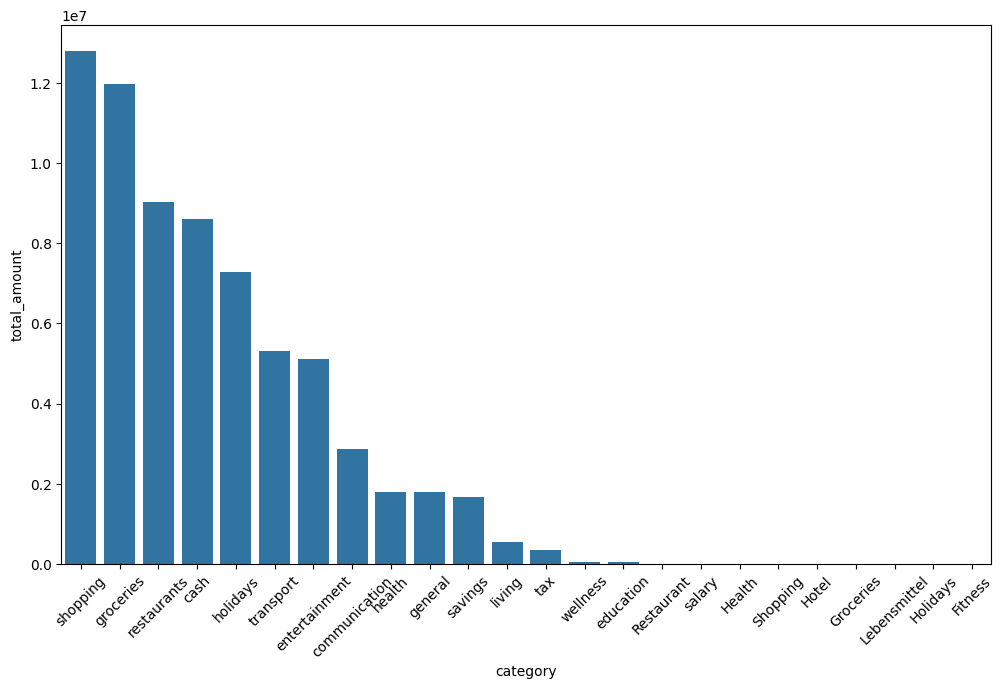

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
plotdata = (
    sow_df.groupby("category")["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)
sns.barplot(plotdata, x="category", y="total_amount")
plt.xticks(rotation=45)
plt.show()

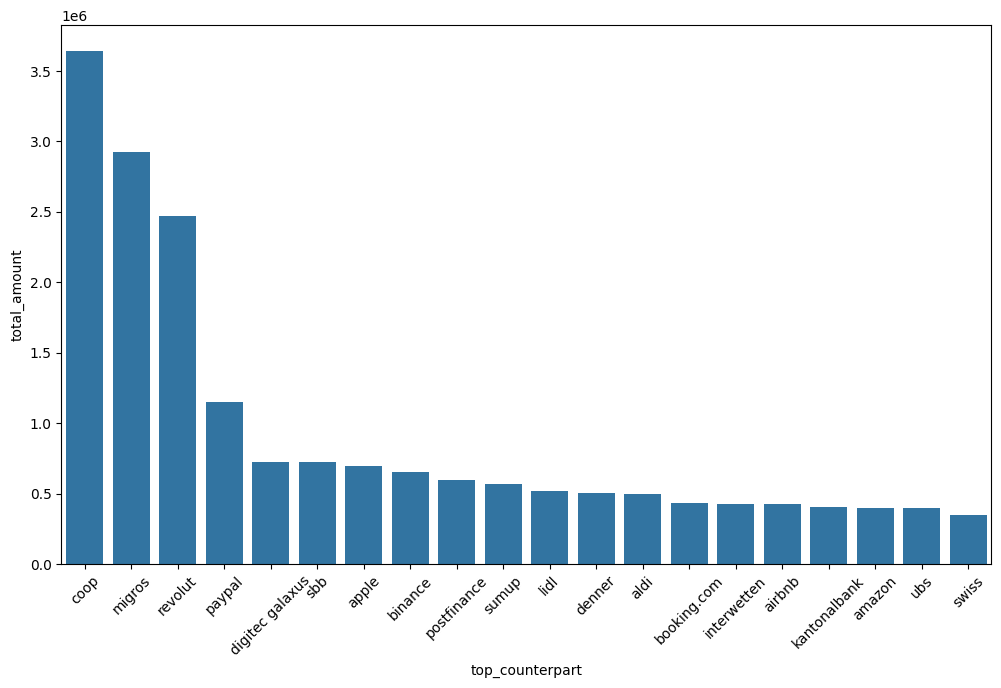

In [16]:
plt.figure(figsize=(12, 7))
plotdata = (
    sow_df[sow_df["top_counterpart"] != "other"]
    .groupby("top_counterpart")["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
    .head(20)
)
sns.barplot(plotdata, x="top_counterpart", y="total_amount")
plt.xticks(rotation=45)
plt.show()

### Churn

In [ ]:
import pandas as pd

customer_df = pd.read_csv("customer_data.csv")
churn_labels = pd.read_csv("customer_data_labels.csv")
churn_predict = pd.read_csv("customer_data_predict.csv")

In [18]:
churn_labels.head()

,customer_id,churned
0,4683,True
1,4514,False
2,619,True
3,1995,True
4,2361,False


In [19]:
churn_predict.head()

,customer_id
0,1447
1,1827
2,3100
3,4645
4,5277


In [20]:
labeled_df = customer_df.merge(churn_labels, on="customer_id")
labeled_df.head()

,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,...,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us,churned
0,0,11,197,21843.61,92,514,0.75,0.25,12620.0,1638.0,...,0.0,19.25,86.0,0.0,0.0,16.0,28.0,42.0,0.0,False
1,1,14,1736,104203.28,468,964,0.54,0.46,11233.0,2231.0,...,0.0,786.15,1325.0,9.0,1.0,5.0,146.0,96.0,4.0,False
2,2,31,3087,197449.56,629,964,0.21,0.79,15395.0,8950.0,...,0.0,27091.00,1632.0,106.0,3.0,93.0,11.0,0.0,59.0,False
3,6,1,227,11991.94,15,213,1.00,0.00,11090.0,0.0,...,0.0,0.00,227.0,0.0,0.0,0.0,0.0,0.0,0.0,False
4,7,2,20,1041.55,9,8,0.19,0.81,836.0,0.0,...,0.0,0.00,12.0,0.0,0.0,8.0,0.0,0.0,0.0,False


In [21]:
unlabeled_df = customer_df.merge(churn_predict, on="customer_id")
unlabeled_df.head()

,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,...,cur_mxn,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us
0,3,5,1412,49291.32,127,930,0.96,0.04,1450.0,291.0,...,0.0,0.0,0.00,1291.0,103.0,0.0,0.0,0.0,0.0,7.0
1,4,5,903,8224.79,183,525,0.95,0.05,0.0,0.0,...,0.0,0.0,0.00,884.0,9.0,0.0,0.0,0.0,8.0,0.0
2,5,11,649,35797.13,85,953,0.67,0.33,0.0,123.0,...,0.0,0.0,76.36,569.0,34.0,5.0,3.0,7.0,0.0,9.0
3,11,11,393,9659.10,159,909,0.56,0.44,340.0,535.0,...,0.0,0.0,142.70,339.0,19.0,0.0,12.0,3.0,0.0,7.0
4,12,1,15,763.00,9,11,1.00,0.00,680.0,0.0,...,0.0,0.0,0.00,15.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
print("Unlabeled:", len(unlabeled_df))
print("Labeled:", len(labeled_df))

print("Churned:", len(labeled_df[labeled_df["churned"] == True]))
print("Not Churned:", len(labeled_df[labeled_df["churned"] == False]))
print(
    "Churn Rate: ",
    len(labeled_df[labeled_df["churned"] == True]) / len(labeled_df),
)


Unlabeled: 1673
Labeled: 3903
Churned: 2140
Not Churned: 1763
Churn Rate:  0.5482961824237765


#### Challenge

Predict labels for the unlabeled.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [24]:
train, test = train_test_split(labeled_df, test_size=0.3, random_state=1)

In [25]:
features = ["n_transactions", "total_amount", "n_counterparts"]
X_train = train.drop("churned", axis=1)
X_test = test.drop("churned", axis=1)
y_train = train["churned"]
y_test = test["churned"]

In [26]:
clf = RandomForestClassifier(
    n_estimators=10, max_depth=None, min_samples_split=2, random_state=0
)
model_fit = clf.fit(X_train, y_train)
scores = cross_val_score(clf, X_train, y_train)
scores.mean()

np.float64(0.7525610891241604)